# Regressão Softmax com dados do MNIST utilizando gradiente descendente estocástico por minibatches

O objetivo deste notebook é ilustrar
- o uso do gradiente estocástico por mini-batchs
- utilizando as classes Dataset e DataLoater.

A apresentação da perda nos gráficos é um pouco diferente da usual, mostrando a perda de cada um dos vários minibatches dentro de cada época, de forma que as épocas são apresentadas com valores fracionários.

## Importação das bibliotecas

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.autograd import Variable
from torch.utils.data import DataLoader

import torchvision
from torchvision.datasets import MNIST

## Dataset e dataloader

### Definição do tamanho do minibatch

In [2]:
batch_size = 100

### Carregamento, criação dataset e do dataloader

In [3]:
dataset_dir = 'MNIST/'

# Load the full MNIST training dataset
full_train_dataset = MNIST(dataset_dir, train=True, download=True,
                      transform=torchvision.transforms.ToTensor())

# Define the split ratio (e.g., 80% for training, 20% for validation)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

# Split the dataset
dataset_train, dataset_val = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])

# Create DataLoaders for training and validation
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False) # No need to shuffle validation data

print(f'Número total de amostras de treinamento original: {len(full_train_dataset)}')
print(f'Número de amostras de treinamento: {len(dataset_train)}')
print(f'Número de amostras de validação: {len(dataset_val)}')
print('Número de minibatches de treinamento:', len(loader_train))
print('Número de minibatches de validação:', len(loader_val))

x_train_sample, y_train_sample = next(iter(loader_train))
print("\nDimensões dos dados de um minibatch de treinamento:", x_train_sample.size())
print("Valores mínimo e máximo dos pixels: ", torch.min(x_train_sample), torch.max(x_train_sample))
print("Tipo dos dados das imagens:         ", type(x_train_sample))
print("Tipo das classes das imagens:       ", type(y_train_sample))

Número total de amostras de treinamento original: 60000
Número de amostras de treinamento: 48000
Número de amostras de validação: 12000
Número de minibatches de treinamento: 480
Número de minibatches de validação: 120

Dimensões dos dados de um minibatch de treinamento: torch.Size([100, 1, 28, 28])


Valores mínimo e máximo dos pixels:  

tensor(0.) tensor(1.)
Tipo dos dados das imagens:          <class 'torch.Tensor'>
Tipo das classes das imagens:        <class 'torch.Tensor'>


### Usando todas as amostras do MNIST

Neste exemplo utilizaremos todas as amostras de treinamento.

In [4]:
# The original `total_samples` was for the full training set. Now we have a split.
n_batches_train = len(loader_train)
n_batches_val = len(loader_val)
total_train_samples = len(dataset_train)
total_val_samples = len(dataset_val)

print(f'Número de minibatches de treinamento: {n_batches_train}')
print(f'Número de minibatches de validação: {n_batches_val}')
print(f'Total de amostras de treinamento: {total_train_samples}')
print(f'Total de amostras de validação: {total_val_samples}')

Número de minibatches de treinamento: 480
Número de minibatches de validação: 120
Total de amostras de treinamento: 48000
Total de amostras de validação: 12000


## Modelo

In [5]:
model = torch.nn.Linear(28*28, 10)

In [6]:
x = torch.ones(28*28).reshape(1, 784)
print(x.shape)
predict = model(x)
predict

torch.Size([1, 784])


tensor([[-0.2656, -0.8542,  0.2632, -0.8695, -0.6673, -0.6797, -0.4795,  0.0110,
          0.0108, -0.4303]], grad_fn=<AddmmBackward0>)

## Treinamento

Durante o treinamento, acompanharemos a perda e a acurácia para os conjuntos de treinamento e validação em cada época.

### Inicialização dos parâmetros

In [7]:
n_epochs = 5
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos parâmetros

In [8]:
train_losses_per_epoch = []
val_losses_per_epoch = []
train_accuracies_per_epoch = []
val_accuracies_per_epoch = []

for epoch in range(n_epochs):
    # Training phase
    model.train() # Set model to training mode
    correct_train = 0
    total_train = 0
    running_train_loss = 0.0

    for i, (x_train, y_train) in enumerate(loader_train):
        inputs = Variable(x_train.view(-1, 28 * 28))
        labels = Variable(y_train)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        # Exercício 1: print ao final de cada minibatch
        print(f'Época: {epoch+1}/{n_epochs}, batch: {i+1}')

    avg_train_loss = running_train_loss / len(loader_train)
    train_accuracy = correct_train / total_train
    train_losses_per_epoch.append(avg_train_loss)
    train_accuracies_per_epoch.append(train_accuracy)

    # Validation phase
    model.eval() # Set model to evaluation mode
    correct_val = 0
    total_val = 0
    running_val_loss = 0.0

    with torch.no_grad(): # Disable gradient calculations during validation
        for x_val, y_val in loader_val:
            inputs_val = Variable(x_val.view(-1, 28 * 28))
            labels_val = Variable(y_val)

            outputs_val = model(inputs_val)
            loss_val = criterion(outputs_val, labels_val)

            running_val_loss += loss_val.item()
            _, predicted_val = torch.max(outputs_val.data, 1)
            total_val += labels_val.size(0)
            correct_val += (predicted_val == labels_val).sum().item()

    avg_val_loss = running_val_loss / len(loader_val)
    val_accuracy = correct_val / total_val
    val_losses_per_epoch.append(avg_val_loss)
    val_accuracies_per_epoch.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{n_epochs}], ' \
          f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}, ' \
          f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}')


Época: 1/5, batch: 1
Época: 1/5, batch: 2
Época: 1/5, batch: 3
Época: 1/5, batch: 4
Época: 1/5, batch: 5
Época: 1/5, batch: 6
Época: 1/5, batch: 7
Época: 1/5, batch: 8
Época: 1/5, batch: 9
Época: 1/5, batch: 10
Época: 1/5, batch: 11
Época: 1/5, batch: 12
Época: 1/5, batch: 13
Época: 1/5, batch: 14
Época: 1/5, batch: 15
Época: 1/5, batch: 16
Época: 1/5, batch: 17
Época: 1/5, batch: 18
Época: 1/5, batch: 19
Época: 1/5, batch: 20


Época: 1/5, batch: 21
Época: 1/5, batch: 22
Época: 1/5, batch: 23
Época: 1/5, batch: 24
Época: 1/5, batch: 25
Época: 1/5, batch: 26
Época: 1/5, batch: 27
Época: 1/5, batch: 28
Época: 1/5, batch: 29
Época: 1/5, batch: 30
Época: 1/5, batch: 31
Época: 1/5, batch: 32
Época: 1/5, batch: 33
Época: 1/5, batch: 34
Época: 1/5, batch: 35
Época: 1/5, batch: 36
Época: 1/5, batch: 37
Época: 1/5, batch: 38
Época: 1/5, batch: 39
Época: 1/5, batch: 40
Época: 1/5, batch: 41
Época: 1/5, batch: 42


Época: 1/5, batch: 43
Época: 1/5, batch: 44
Época: 1/5, batch: 45
Época: 1/5, batch: 46
Época: 1/5, batch: 47
Época: 1/5, batch: 48
Época: 1/5, batch: 49
Época: 1/5, batch: 50
Época: 1/5, batch: 51
Época: 1/5, batch: 52
Época: 1/5, batch: 53
Época: 1/5, batch: 54
Época: 1/5, batch: 55
Época: 1/5, batch: 56
Época: 1/5, batch: 57
Época: 1/5, batch: 58
Época: 1/5, batch: 59
Época: 1/5, batch: 60
Época: 1/5, batch: 61
Época: 1/5, batch: 62
Época: 1/5, batch: 63
Época: 1/5, batch: 64


Época: 1/5, batch: 65
Época: 1/5, batch: 66
Época: 1/5, batch: 67
Época: 1/5, batch: 68
Época: 1/5, batch: 69
Época: 1/5, batch: 70
Época: 1/5, batch: 71
Época: 1/5, batch: 72
Época: 1/5, batch: 73
Época: 1/5, batch: 74
Época: 1/5, batch: 75
Época: 1/5, batch: 76
Época: 1/5, batch: 77
Época: 1/5, batch: 78
Época: 1/5, batch: 79
Época: 1/5, batch: 80
Época: 1/5, batch: 81
Época: 1/5, batch: 82
Época: 1/5, batch: 83
Época: 1/5, batch: 84
Época: 1/5, batch: 85


Época: 1/5, batch: 86
Época: 1/5, batch: 87
Época: 1/5, batch: 88
Época: 1/5, batch: 89
Época: 1/5, batch: 90
Época: 1/5, batch: 91
Época: 1/5, batch: 92
Época: 1/5, batch: 93
Época: 1/5, batch: 94
Época: 1/5, batch: 95
Época: 1/5, batch: 96
Época: 1/5, batch: 97
Época: 1/5, batch: 98
Época: 1/5, batch: 99
Época: 1/5, batch: 100
Época: 1/5, batch: 101
Época: 1/5, batch: 102
Época: 1/5, batch: 103
Época: 1/5, batch: 104
Época: 1/5, batch: 105
Época: 1/5, batch: 106


...

Época: 5/5, batch: 415
Época: 5/5, batch: 416
Época: 5/5, batch: 417
Época: 5/5, batch: 418
Época: 5/5, batch: 419
Época: 5/5, batch: 420
Época: 5/5, batch: 421
Época: 5/5, batch: 422
Época: 5/5, batch: 423
Época: 5/5, batch: 424
Época: 5/5, batch: 425
Época: 5/5, batch: 426
Época: 5/5, batch: 427
Época: 5/5, batch: 428
Época: 5/5, batch: 429
Época: 5/5, batch: 430
Época: 5/5, batch: 431
Época: 5/5, batch: 432
Época: 5/5, batch: 433
Época: 5/5, batch: 434


Época: 5/5, batch: 435
Época: 5/5, batch: 436
Época: 5/5, batch: 437
Época: 5/5, batch: 438
Época: 5/5, batch: 439
Época: 5/5, batch: 440
Época: 5/5, batch: 441
Época: 5/5, batch: 442
Época: 5/5, batch: 443
Época: 5/5, batch: 444
Época: 5/5, batch: 445
Época: 5/5, batch: 446
Época: 5/5, batch: 447
Época: 5/5, batch: 448
Época: 5/5, batch: 449
Época: 5/5, batch: 450
Época: 5/5, batch: 451
Época: 5/5, batch: 452
Época: 5/5, batch: 453
Época: 5/5, batch: 454
Época: 5/5, batch: 455
Época: 5/5, batch: 456


Época: 5/5, batch: 457
Época: 5/5, batch: 458
Época: 5/5, batch: 459
Época: 5/5, batch: 460
Época: 5/5, batch: 461
Época: 5/5, batch: 462
Época: 5/5, batch: 463
Época: 5/5, batch: 464
Época: 5/5, batch: 465
Época: 5/5, batch: 466
Época: 5/5, batch: 467
Época: 5/5, batch: 468
Época: 5/5, batch: 469
Época: 5/5, batch: 470
Época: 5/5, batch: 471
Época: 5/5, batch: 472
Época: 5/5, batch: 473
Época: 5/5, batch: 474
Época: 5/5, batch: 475
Época: 5/5, batch: 476
Época: 5/5, batch: 477
Época: 5/5, batch: 478


Época: 5/5, batch: 479
Época: 5/5, batch: 480


Epoch [5/5], Train Loss: 30.1558, Train Acc: 0.1106, Val Loss: 24.5816, Val Acc: 0.1017


In [9]:
print('--- Treinamento Finalizado ---')
print(f'Última perda de treinamento: {train_losses_per_epoch[-1]:.4f}')
print(f'Última acurácia de treinamento: {train_accuracies_per_epoch[-1]:.4f}')
print(f'Última perda de validação: {val_losses_per_epoch[-1]:.4f}')
print(f'Última acurácia de validação: {val_accuracies_per_epoch[-1]:.4f}')

--- Treinamento Finalizado ---
Última perda de treinamento: 30.1558
Última acurácia de treinamento: 0.1106
Última perda de validação: 24.5816
Última acurácia de validação: 0.1017


### Visualizando a evolução da perda e acurácia

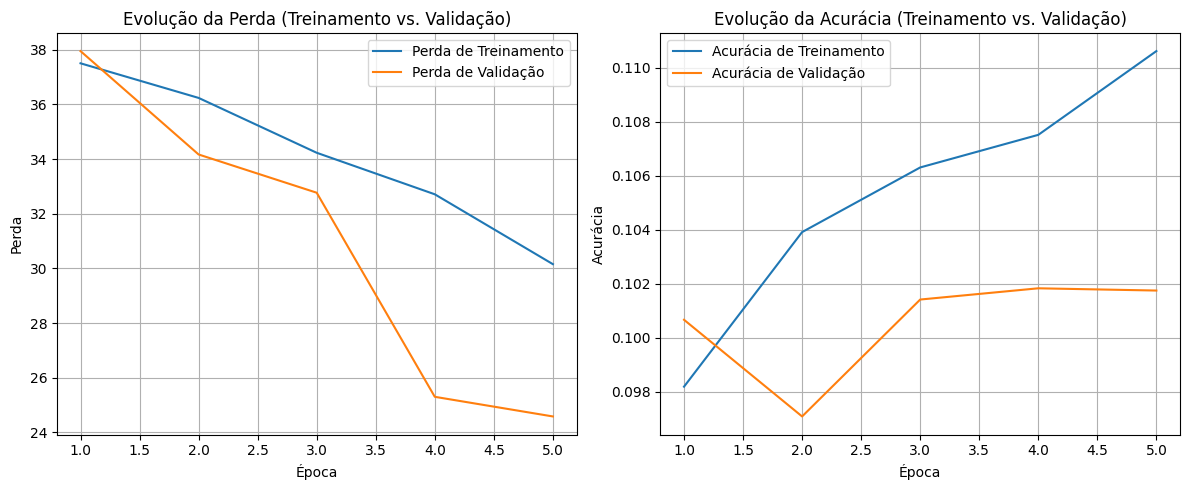

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, n_epochs + 1), train_losses_per_epoch, label='Perda de Treinamento')
plt.plot(range(1, n_epochs + 1), val_losses_per_epoch, label='Perda de Validação')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.title('Evolução da Perda (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, n_epochs + 1), train_accuracies_per_epoch, label='Acurácia de Treinamento')
plt.plot(range(1, n_epochs + 1), val_accuracies_per_epoch, label='Acurácia de Validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Evolução da Acurácia (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Observações sobre os gráficos

Estes gráficos mostram a perda e a acurácia calculadas ao final de cada época para os conjuntos de treinamento e validação. Idealmente, a perda de treinamento e validação deve diminuir, e a acurácia deve aumentar, com as curvas de validação seguindo de perto as de treinamento. Divergências significativas podem indicar overfitting ou underfitting.

# Atividades

## Perguntas

1. Qual é o tamanho do mini-batch?

R.: 100 amostras, definido por `batch_size = 100`.

2. Em uma época, quantos mini-batches existem?

R.: 480 mini-batches de treinamento (48.000 amostras de treino ÷ 100 por batch) e 120 mini-batches de validação (12.000 amostras ÷ 100).

3. Qual é a definição de época?

R.: Uma época é uma passagem completa por todo o conjunto de treinamento. Em cada época, o modelo processa todos os mini-batches uma vez, atualizando os pesos a cada mini-batch.


## Exercícios


1. Coloque um print no final de cada minibatch, no mesmo estilo do print do final de época, no seguinte estilo:
    - Época: 1/4, batch: 600
2. Altere o tamanho de minibatch (batch_size) algumas vezes, refaça o treinamento, e compare no gráfico abaixo a queda da perda para cada tamanho de minibatch.

### Exercício 2 — Comparação da perda para diferentes tamanhos de mini-batch

Retreinamos o modelo com `batch_size` em 4 valores: 16, 64, 256 e 1024, e comparamos a curva de perda de treinamento por época.


batch_size=   16 | perda final: 31.4622


batch_size=   64 | perda final: 30.8600


batch_size=  256 | perda final: 34.4724


batch_size= 1024 | perda final: 38.9967


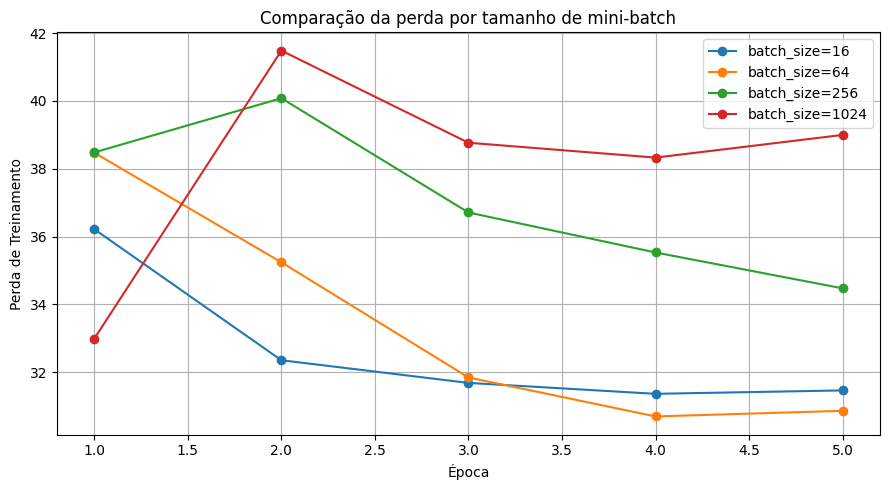

In [11]:
# Exercício 2: comparação da perda para diferentes batch sizes
batch_sizes_to_test = [16, 64, 256, 1024]
results_losses = {}

for bs in batch_sizes_to_test:
    # Recria DataLoaders com o novo batch_size
    loader_bs = DataLoader(dataset_train, batch_size=bs, shuffle=True)

    # Reinicializa o modelo e otimizador
    model_bs = torch.nn.Linear(28*28, 10)
    optimizer_bs = torch.optim.SGD(model_bs.parameters(), lr=learningRate)

    losses_bs = []
    for epoch in range(n_epochs):
        model_bs.train()
        running_loss = 0.0
        for x_b, y_b in loader_bs:
            inputs_b = Variable(x_b.view(-1, 28 * 28))
            labels_b = Variable(y_b)
            outputs_b = model_bs(inputs_b)
            loss_b = criterion(outputs_b, labels_b)
            optimizer_bs.zero_grad()
            loss_b.backward()
            optimizer_bs.step()
            running_loss += loss_b.item()
        losses_bs.append(running_loss / len(loader_bs))

    results_losses[bs] = losses_bs
    print(f'batch_size={bs:5d} | perda final: {losses_bs[-1]:.4f}')

# Gráfico comparativo
plt.figure(figsize=(9, 5))
for bs, losses in results_losses.items():
    plt.plot(range(1, n_epochs + 1), losses, marker='o', label=f'batch_size={bs}')
plt.xlabel('Época')
plt.ylabel('Perda de Treinamento')
plt.title('Comparação da perda por tamanho de mini-batch')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Conclusões sobre os experimentos deste notebook

- Mini-batches menores (ex.: 16) geram atualizações mais ruidosas mas podem convergir mais rápido nas primeiras épocas.
- Mini-batches maiores (ex.: 1024) produzem gradientes mais estáveis, porém podem precisar de mais épocas para convergir.
- O `batch_size=100` utilizado no treinamento principal representa um bom equilíbrio entre estabilidade e velocidade.
- O uso do `DataLoader` com `shuffle=True` é essencial para que o SGD por mini-batch funcione corretamente, evitando que o modelo veja sempre os mesmos batches na mesma ordem.
